In [39]:
import pandas as pd
import matplotlib.pyplot as plt
import math
import os
import sys
from tqdm.auto import tqdm
from time_series import create_time_series
sys.path.insert(0, os.path.abspath("../fsrs-optimizer/src/fsrs_optimizer/"))
import fsrs_optimizer
import numpy as np

tqdm.pandas()

In [40]:
# Review count: User id
# Median: 8798
# Most: 6810

USER_ID = 50
df = pd.read_parquet(
    "../anki-revlogs-10k/revlogs", filters=[("user_id", "=", USER_ID), ("rating", "in", [1, 2, 3, 4])], columns=["card_id", "day_offset", "rating", "elapsed_days", "duration"] 
)
df.size

91585

In [41]:
df.describe()

,card_id,day_offset,rating,elapsed_days,duration
count,18317.000000,18317.000000,18317.000000,18317.000000,18317.000000
mean,1339.709723,475.811923,2.728504,12.837146,18959.643774
std,709.041156,120.933315,0.531948,36.183503,18388.036945
min,0.000000,0.000000,1.000000,-1.000000,861.000000
25%,753.000000,423.000000,3.000000,0.000000,5944.000000
50%,1276.000000,462.000000,3.000000,2.000000,11000.000000
75%,1950.000000,519.000000,3.000000,9.000000,24661.000000
max,2648.000000,919.000000,4.000000,594.000000,60000.000000


In [42]:
df[df["card_id"] == 230]

,card_id,day_offset,rating,elapsed_days,duration
1340,230,42,2,-1,11321
1341,230,42,2,0,3913
1342,230,206,3,164,9377
1343,230,206,3,0,3005
1344,230,487,3,281,5446
1345,230,487,3,0,5332
1346,230,508,3,21,4351
1347,230,590,3,82,10509


In [43]:
df["prior_reviews"] = df.groupby("day_offset").cumcount()

In [44]:
print("creating time series")
df["delta_t"] = df["elapsed_days"]
df: pd.DataFrame = create_time_series(df)
print("training")
trainer = fsrs_optimizer.Trainer(df, df, fsrs_optimizer.DEFAULT_PARAMETER)
w = trainer.train()

creating time series
training


train:  64%|██████▍   | 6144/9594 [00:00<00:00, 23860.40it/s]

iteration: 768
w: [0.4026, 1.2098, 3.1992, 15.691, 7.1658, 0.5624, 1.4393, 0.0311, 1.5746, 0.1164, 1.0481, 1.9626, 0.087, 0.3191, 2.2922, 0.2577, 3.0029, 0.5439, 0.6893]
iteration: 1536
w: [0.4026, 1.2331, 3.2183, 15.691, 7.1503, 0.5772, 1.4364, 0.0398, 1.5897, 0.1065, 1.0634, 1.9771, 0.0727, 0.3335, 2.3053, 0.2689, 3.0172, 0.5674, 0.7125]
iteration: 2304
w: [0.4026, 1.2503, 3.2356, 15.691, 7.1478, 0.5767, 1.4461, 0.0319, 1.5908, 0.1127, 1.0649, 1.9902, 0.0597, 0.3467, 2.3168, 0.2691, 3.0288, 0.5879, 0.7333]
iteration: 3072
w: [0.4026, 1.2643, 3.2477, 15.691, 7.1356, 0.5862, 1.4518, 0.0312, 1.6018, 0.1094, 1.0761, 1.9998, 0.0503, 0.3562, 2.328, 0.2714, 3.0419, 0.6044, 0.75]
iteration: 3840
w: [0.4026, 1.2763, 3.2568, 15.691, 7.1202, 0.5996, 1.4551, 0.0342, 1.6164, 0.1019, 1.0909, 2.0059, 0.0443, 0.3622, 2.3352, 0.2788, 3.0516, 0.6183, 0.7638]
iteration: 4608
w: [0.4026, 1.2854, 3.2644, 15.691, 7.1103, 0.6073, 1.4615, 0.0319, 1.6253, 0.0988, 1.0999, 2.011, 0.0393, 0.3673, 2.3406, 0.2797

train: 100%|██████████| 9594/9594 [00:00<00:00, 22516.89it/s]


iteration: 6912
w: [0.4026, 1.2968, 3.2739, 15.691, 7.1121, 0.6019, 1.4844, 0.0123, 1.6212, 0.1115, 1.0961, 2.0298, 0.0207, 0.3867, 2.3548, 0.2643, 3.0703, 0.6442, 0.7899]
iteration: 7680
w: [0.4026, 1.2981, 3.2747, 15.691, 7.1118, 0.6016, 1.4874, 0.0099, 1.6212, 0.1125, 1.096, 2.0301, 0.0205, 0.3871, 2.3548, 0.2621, 3.0734, 0.6457, 0.7915]
iteration: 8448
w: [0.4026, 1.2988, 3.2751, 15.691, 7.1115, 0.6016, 1.4888, 0.0087, 1.6212, 0.1129, 1.0961, 2.0298, 0.021, 0.3868, 2.3547, 0.2613, 3.075, 0.6465, 0.7922]
iteration: 9216
w: [0.4026, 1.299, 3.2754, 15.691, 7.1115, 0.6015, 1.4892, 0.0084, 1.6212, 0.1131, 1.0961, 2.0297, 0.0211, 0.3868, 2.3547, 0.261, 3.0755, 0.6467, 0.7925]


In [45]:
import math

DECAY = -0.5
FACTOR = 0.9 ** (1 / DECAY) - 1

def power_forgetting_curve(t, s):
    return (1 + FACTOR * t / s) ** DECAY

def stability_after_success(s, r, d, rating):
    hard_penalty = w[15] if rating == 2 else 1
    easy_bonus = w[16] if rating == 4 else 1
    return max(
        0.01,
        s * (
            1
            + math.exp(w[8])
            * (11 - d)
            * (s ** -w[9])
            * (math.exp((1 - r) * w[10]) - 1)
            * hard_penalty
            * easy_bonus
        )
    )

def stability_after_failure(s, r, d):
    return max(
        0.01,
        min(
            w[11]
            * (d ** -w[12])
            * ((s + 1) ** w[13] - 1)
            * math.exp((1 - r) * w[14]),
            s / math.exp(w[17] * w[18])
        )
    )

def stability_short_term(s, init_rating=None):
    if init_rating is not None:
        rating_offset = fsrs_optimizer.DEFAULT_FIRST_RATING_OFFSETS[init_rating - 1]
        session_len = fsrs_optimizer.DEFAULT_FIRST_SESSION_LENS[init_rating - 1]
    else:
        rating_offset = fsrs_optimizer.DEFAULT_FORGET_RATING_OFFSET
        session_len = fsrs_optimizer.DEFAULT_FORGET_SESSION_LEN
    
    new_s = s * math.exp(
        w[17] * (rating_offset + session_len * w[18])
    )
    return new_s

def init_d(rating):
    return w[4] - math.exp(w[5] * (rating - 1)) + 1

def init_d_with_short_term(rating):
    rating_offset = fsrs_optimizer.DEFAULT_FIRST_RATING_OFFSETS[rating - 1]
    new_d = init_d(rating) - w[6] * rating_offset
    return max(1, min(new_d, 10))

def linear_damping(delta_d, old_d):
    return delta_d * (10 - old_d) / 9

def mean_reversion(init, current):
    return w[7] * init + (1 - w[7]) * current

def next_d(d, rating):
    delta_d = -w[6] * (rating - 3)
    new_d = d + linear_damping(delta_d, d)
    new_d = mean_reversion(init_d(4), new_d)
    return max(1, min(new_d, 10))


In [46]:
def memory_state(df):
    t_history = [int(t) for t in df["t_history"].split(",")]
    r_history = [int(r) for r in df["r_history"].split(",")]
    difficulty = None
    stability = None
    retrievability = 1e-10
    for delta_t, rating in zip(t_history, r_history):
        if stability is None:  # New card
            difficulty = init_d_with_short_term(rating)
            stability = stability_short_term(w[rating - 1], init_rating=rating)
        else:
            retrievability = power_forgetting_curve(delta_t, stability)
            if rating > 1:
                stability = stability_after_success(
                    stability, retrievability, difficulty, rating
                )
            else:
                stability = stability_after_failure(stability, retrievability, difficulty)
                stability = stability_short_term(stability)
            difficulty = next_d(difficulty, rating)
            if rating == 1:
                difficulty -= (w[6] * fsrs_optimizer.DEFAULT_FORGET_RATING_OFFSET)
                difficulty = min(max(difficulty, 1), 10)

    return stability, difficulty, retrievability


df["s"], df["d"], df["r"] = zip(*df.progress_apply(memory_state, axis=1))

100%|██████████| 9594/9594 [00:00<00:00, 60861.12it/s]


In [47]:
df["loss"] = df.apply(lambda df: (df["y"] - df["r"]) ** 2, axis=1)
# df["duration"] = (df["duration"] / 1000).round(0) Ok what the hell is wrong with my past self?

Average Very Young cards per day 1.4436421981548335


<Figure size 640x480 with 0 Axes>

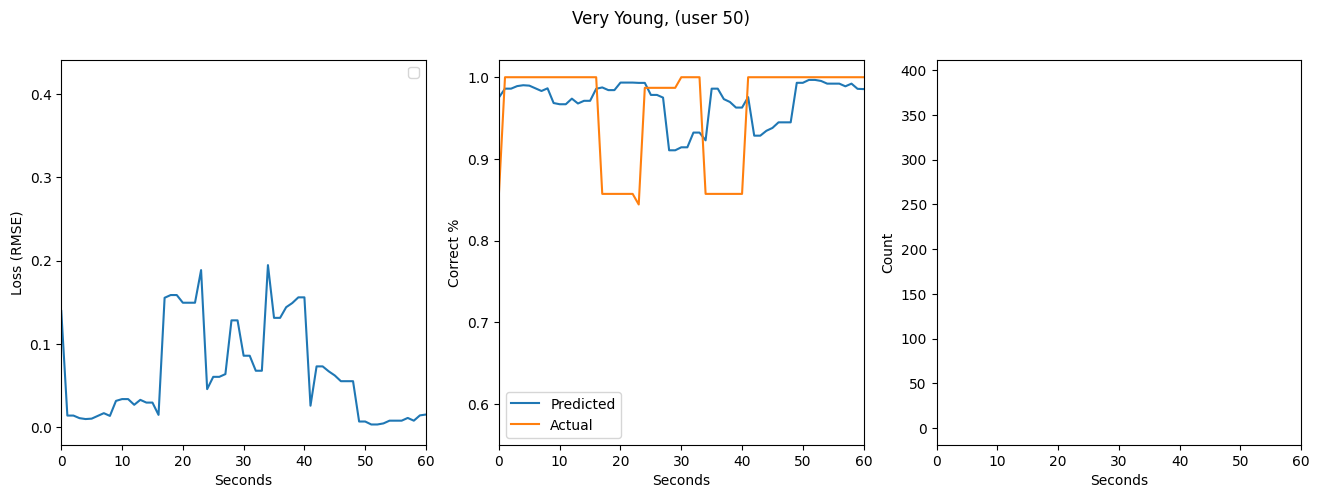

Average Young cards per day 1.5255922165820643


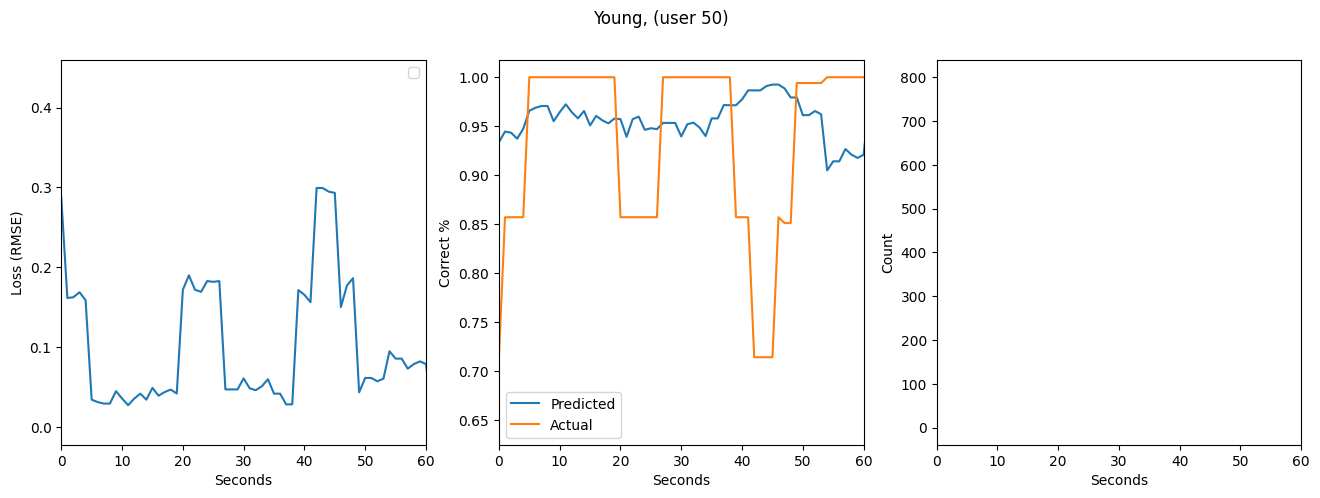

Average Mature cards per day 1.3031518624641834


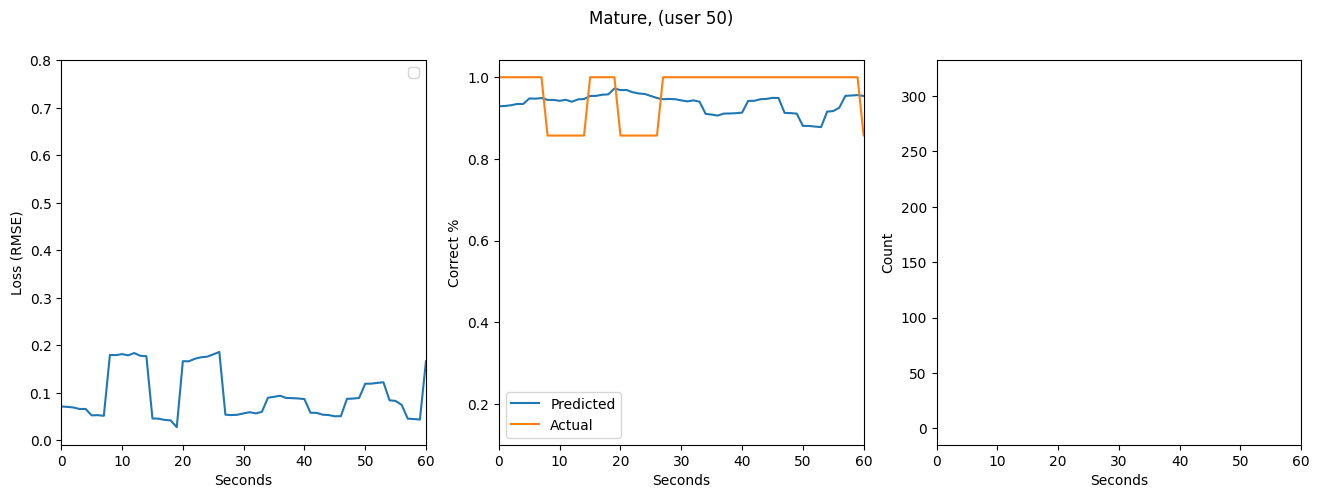

Average All cards per day 1.5351132686084143


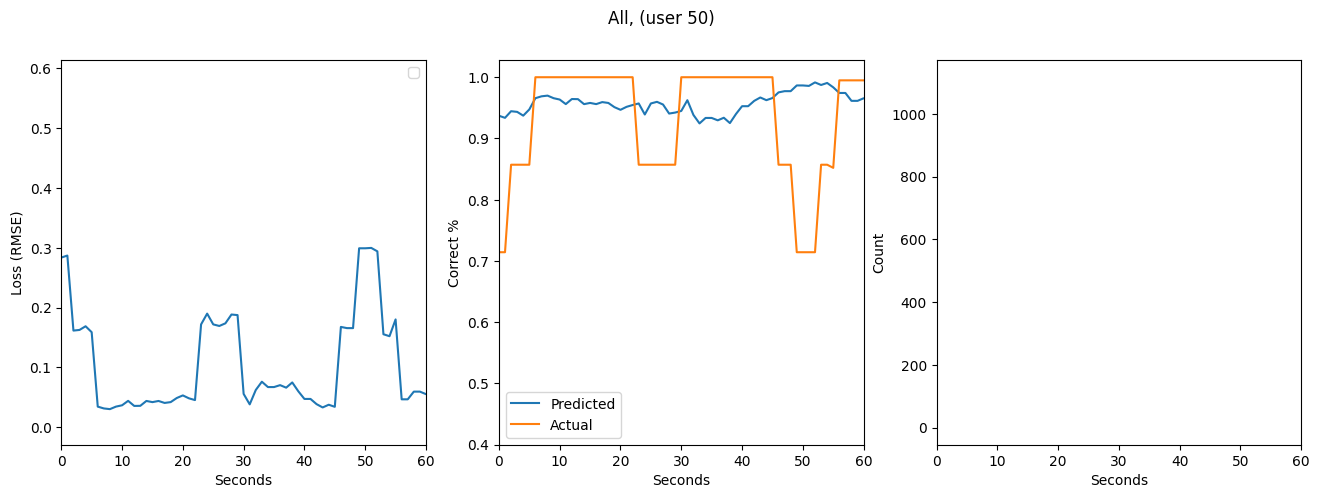

In [48]:
plt.clf()
categories = [
    #("Learn", -1, 1), 
    ("Very Young", 0, 4), 
    ("Young", 0, 21), 
    ("Mature", 21, 1e20),
    ("All", -1, 1e20)
]

# https://stackoverflow.com/a/54628145/24162642
def moving_average(x, w):
    return np.convolve(x, np.ones(w), 'valid') / w

for name, lower, upper in categories:
    df_filtered = df[(df["elapsed_days"] > lower) & (df["elapsed_days"] <= upper) & (df["r"] > 1e-9)].groupby("duration")

    print(f"Average {name} cards per day {df_filtered['card_id'].count().mean()}")
    loss = df_filtered["loss"].mean() ** 0.5
    loss = moving_average(loss, 7)

    fig = plt.figure(figsize=(16, 5))
    fig.suptitle(f"{name}, (user {USER_ID})")
    ax1 = fig.add_subplot(131)
    xlim = 60

    ax1.set_xlabel('Seconds')
    ax1.set_ylabel('Loss (RMSE)')
    ax1.plot(loss)
    ax1.legend()
    ax1.set_xlim(0, xlim)


    ax2 = fig.add_subplot(132)

    ax2.plot(moving_average(df_filtered["r"].mean(), 7), label="Predicted")
    ax2.plot(moving_average(df_filtered["y"].mean(), 7), label="Actual")
    ax2.set_xlabel('Seconds')
    ax2.set_ylabel('Correct %')
    ax2.set_xlim(0, xlim)
    ax2.legend()

    ax3 = fig.add_subplot(133)

    ax3.plot(df_filtered["r"].count())
    ax3.set_xlabel('Seconds')
    ax3.set_ylabel('Count') # Number of days that the user had that many reviews or more
    ax3.set_xlim(0, xlim)

    plt.show()


In [49]:
df_filtered = df[(df["elapsed_days"] > 0) & (df["r"] > 0.7)]
df_filtered.sort_values("elapsed_days", inplace=True)

/tmp/ipykernel_26410/3107958746.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtered.sort_values("elapsed_days", inplace=True)


# Current residual

The average per rating - the actual duration

In [79]:
groups = df_filtered.groupby("rating")["duration"].mean()

df_filtered["review_average"] = df_filtered["duration"] - df_filtered["rating"].map(groups)

current_residual = df_filtered.groupby("rating").apply(lambda x: abs(x["review_average"]).mean())

current_residual, groups

/tmp/ipykernel_26410/1319187014.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtered["review_average"] = df_filtered["duration"] - df_filtered["rating"].map(groups)
/tmp/ipykernel_26410/1319187014.py:5: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  current_residual = df_filtered.groupby("rating").apply(lambda x: abs(x["review_average"]).mean())


(rating
 1.0    17699.259510
 2.0    16368.268466
 3.0    13090.191158
 4.0     9987.145833
 dtype: float64,
 rating
 1.0    31370.015306
 2.0    28608.107781
 3.0    17207.863004
 4.0    13163.097222
 Name: duration, dtype: float64)

In [106]:
def duration_plot(df, x_col, axes, label, current):
    df.sort_values(x_col, inplace=True)
    x = df[x_col]
    y = df["duration"]

    # groups = df.groupby(x_col)["duration"].mean()
    c = np.polyfit(x, y, 3)
    axes.plot(x, np.polyval(c, x), color="orange")
    axes.scatter(x, y, s=0.1)

    residual = abs(y - np.polyval(c, x)).mean()
    axes.set_title(f"{label} residual:{float(residual):.2f} improvement:{float(current-residual):.2f}")
    axes.set_xlabel(x_col)
    axes.set_ylabel("duration (ms)")

def duration_plot_ratings(x, df = df_filtered):
    fig = plt.figure(figsize=(12, 12))
    for rating in range(1, 5):
        duration_plot(df[df["rating"] == rating], x, fig.add_subplot(2, 2, rating), f"{rating=}", current_residual[rating])

/tmp/ipykernel_26410/2040779077.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.sort_values(x_col, inplace=True)


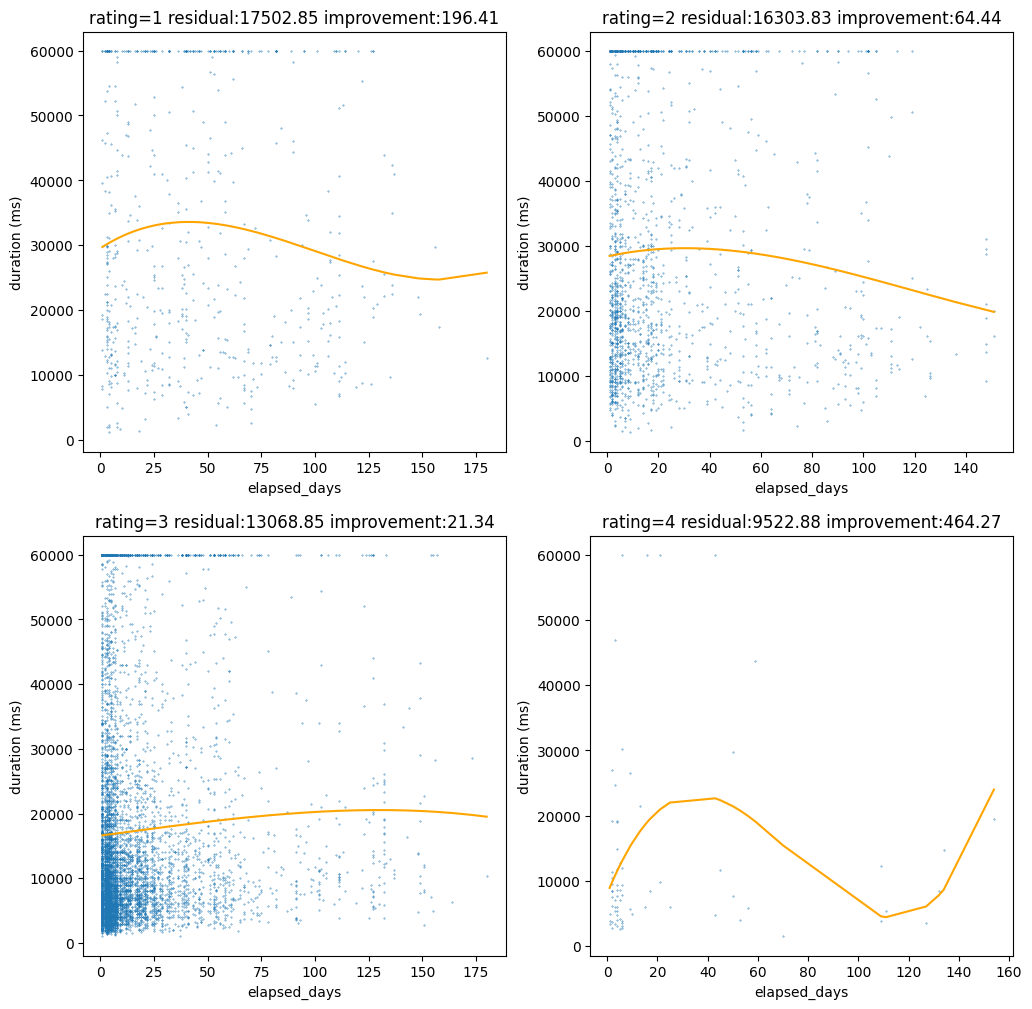

In [107]:
duration_plot_ratings("elapsed_days")

/tmp/ipykernel_26410/2040779077.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.sort_values(x_col, inplace=True)


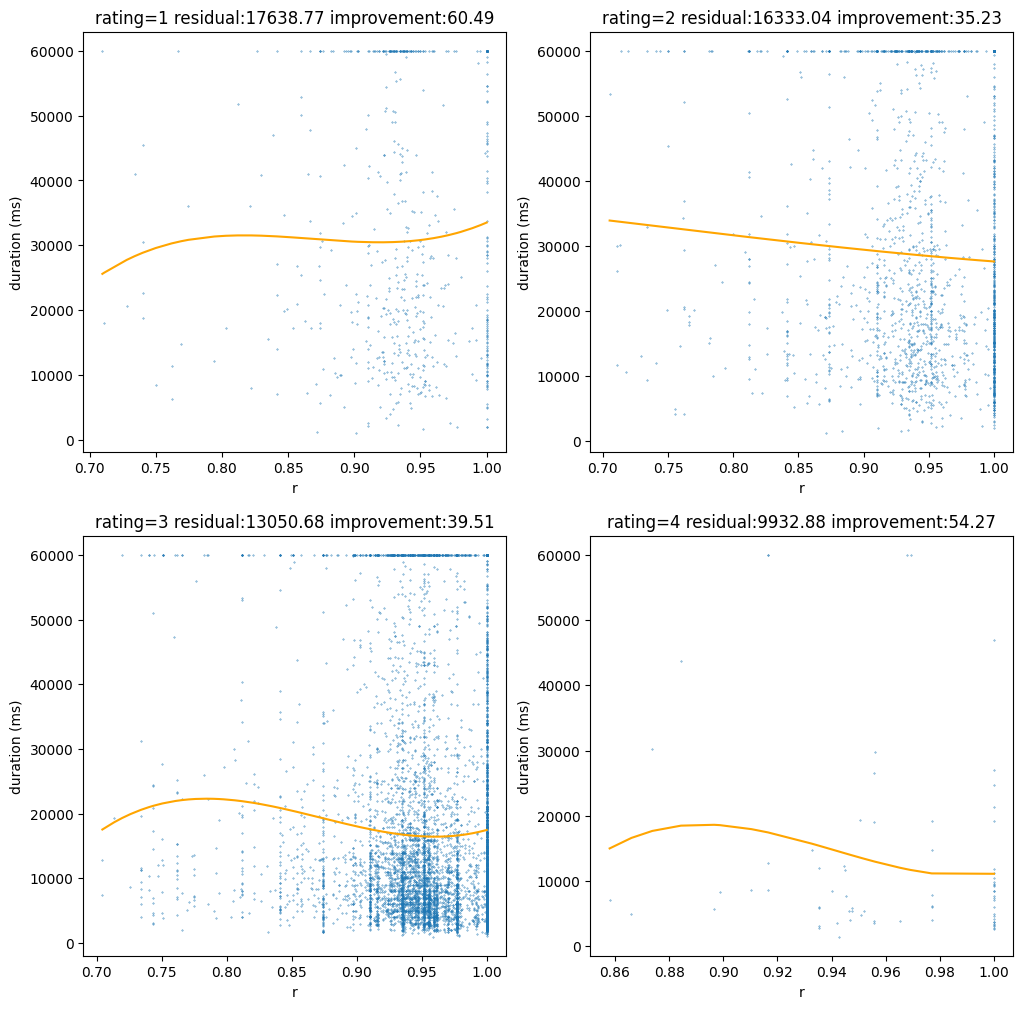

In [108]:
duration_plot_ratings("r")

/tmp/ipykernel_26410/2040779077.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.sort_values(x_col, inplace=True)


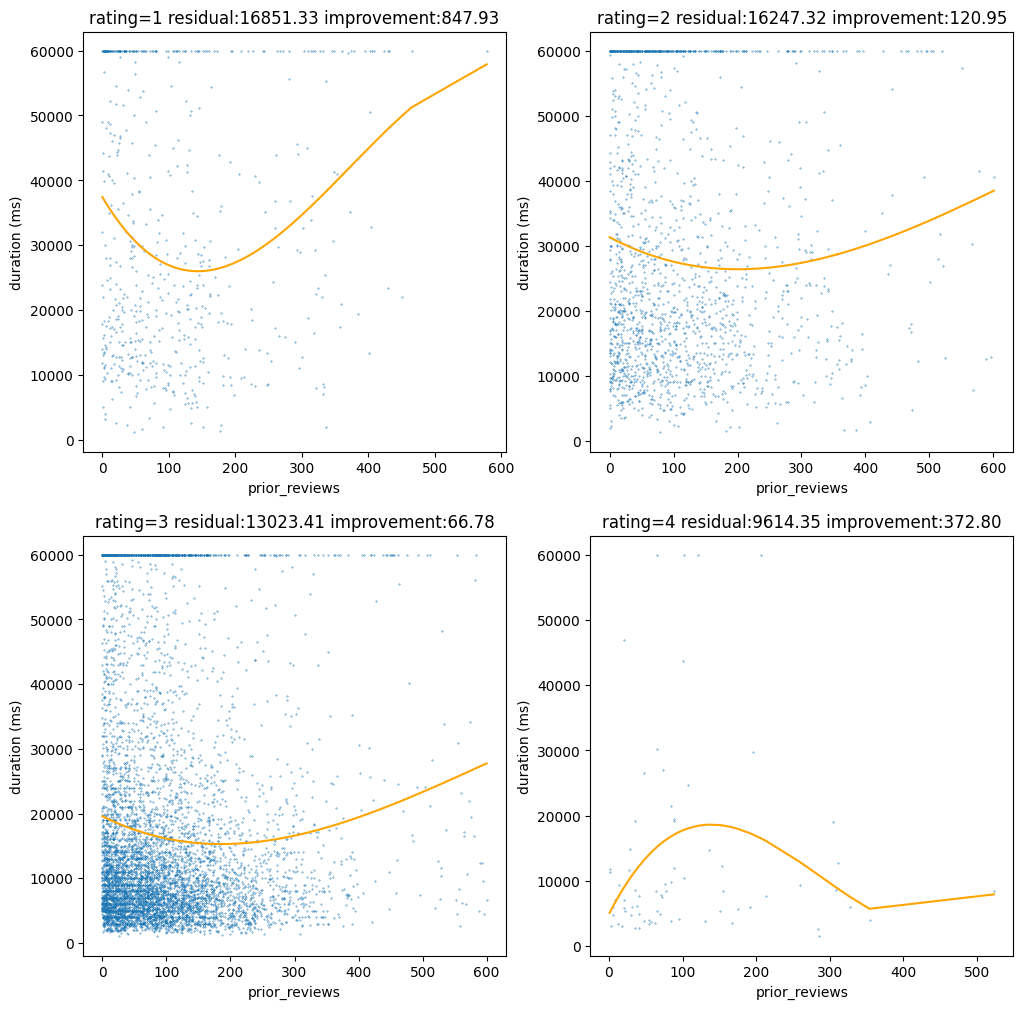

In [109]:
df["prior_reviews"] = df.groupby("day_offset").cumcount()
duration_plot_ratings("prior_reviews")